In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

In [2]:
data=pd.read_csv(f"Indian Liver Patient Dataset (ILPD).csv")
data.head()

,age,gender,tot_bilirubin,direct_bilirubin,tot_proteins,albumin,ag_ratio,sgpt,sgot,alkphos,is_patient
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               583 non-null    int64  
 1   gender            583 non-null    str    
 2   tot_bilirubin     583 non-null    float64
 3   direct_bilirubin  583 non-null    float64
 4   tot_proteins      583 non-null    int64  
 5   albumin           583 non-null    int64  
 6   ag_ratio          583 non-null    int64  
 7   sgpt              583 non-null    float64
 8   sgot              583 non-null    float64
 9   alkphos           579 non-null    float64
 10  is_patient        583 non-null    int64  
dtypes: float64(5), int64(5), str(1)
memory usage: 52.8 KB


In [4]:
data.shape

(583, 11)

In [5]:
data['alkphos'] = data['alkphos'].fillna(data['alkphos'].median())
data['alkphos'].isna().sum()


np.int64(0)

In [6]:
data.columns

Index(['age', 'gender', 'tot_bilirubin', 'direct_bilirubin', 'tot_proteins',
       'albumin', 'ag_ratio', 'sgpt', 'sgot', 'alkphos', 'is_patient'],
      dtype='str')

In [7]:
# Binary encoding for gender
data['gender'] = data['gender'].map({'Male': 1, 'Female': 0})

In [8]:
# 3. Feature Engineering (Improving Model Intelligence)
# Create the AST/ALT Ratio (Clinical marker for liver damage)
data['ast_alt_ratio'] = data['sgot'] / data['sgpt']

In [9]:
# Create a more precise Albumin/Globulin ratio
# Globulin = Total Proteins - Albumin
data['calc_ag_ratio'] = data['albumin'] / (data['tot_proteins'] - data['albumin'])

In [10]:
# 4. Feature Selection
# We drop 'is_patient' (target) and 'direct_bilirubin' 
# (Highly redundant with 'tot_bilirubin', removing it reduces noise)
X = data.drop(['is_patient'], axis=1)
y = data['is_patient']

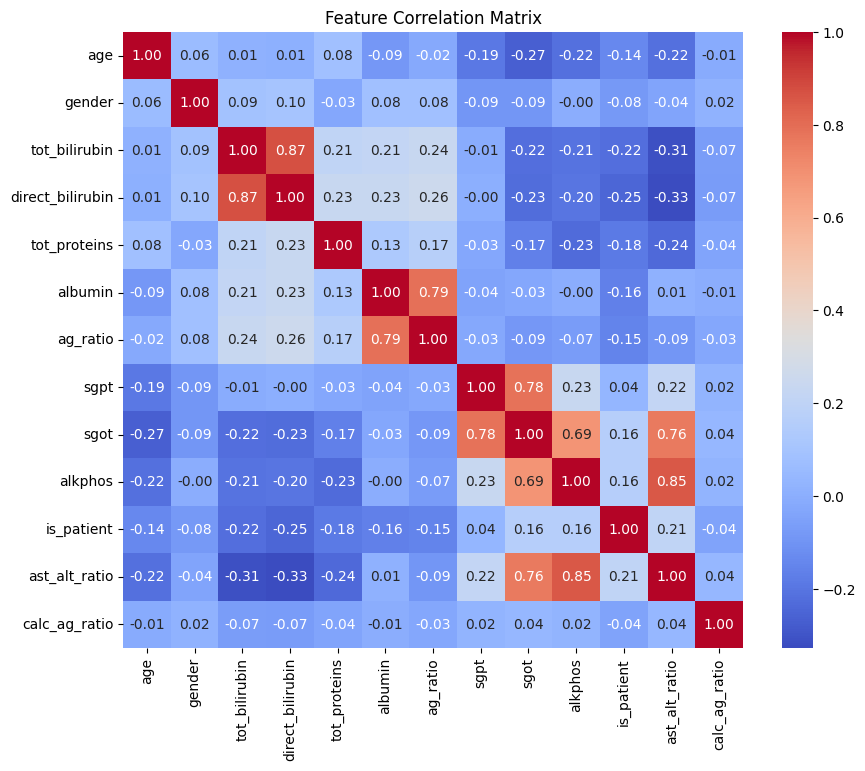

In [11]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()


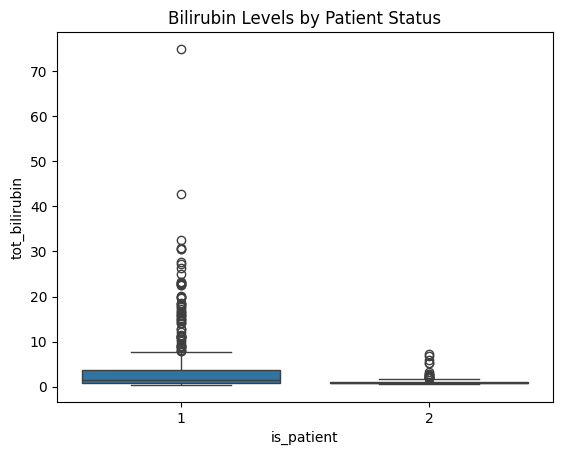

In [12]:

# Boxplot: Comparing Bilirubin levels for Patients vs Non-Patients
sns.boxplot(x='is_patient', y='tot_bilirubin', data=data)
plt.title('Bilirubin Levels by Patient Status')
plt.show()

In [13]:
#X=data.drop(['is_patient'],axis=1)
#y=data[['is_patient']]

In [14]:
model=RandomForestClassifier(n_estimators=50,criterion='gini',max_depth=15,
                             min_samples_leaf=3,random_state=42)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42,stratify=y)

In [16]:
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

In [17]:
rf_model=model.fit(X_train,y_train)

In [18]:

y_pred = rf_model.predict(X_test)
# 4. Evaluate the Results
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Overall Accuracy: 76.27%

Classification Report:
              precision    recall  f1-score   support

           1       0.89      0.76      0.82        42
           2       0.57      0.76      0.65        17

    accuracy                           0.76        59
   macro avg       0.73      0.76      0.74        59
weighted avg       0.80      0.76      0.77        59



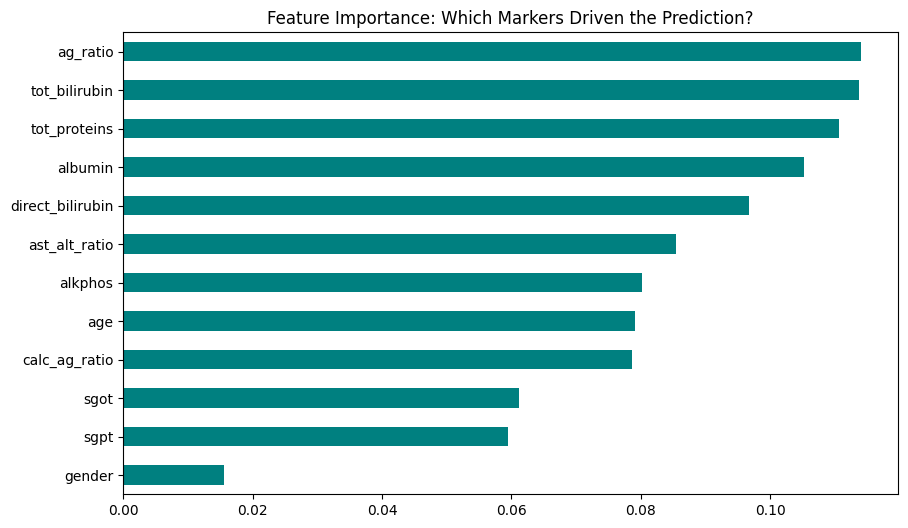

In [19]:
# 9. Visualizing Feature Importance
plt.figure(figsize=(10, 6))
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance: Which Markers Driven the Prediction?')
plt.show()

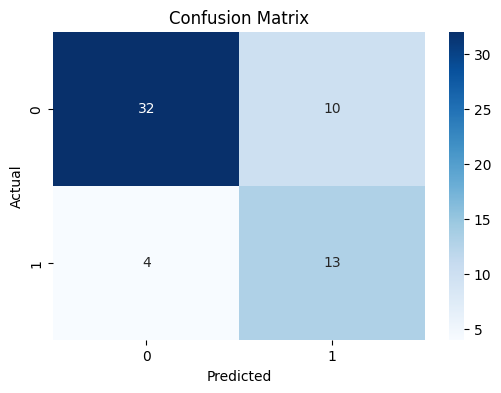

In [20]:
# 10. Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()